# Retrieval Query Strategy Comparison (Qdrant)

This notebook evaluates three retrieval query strategies over 10 random samples from `evaluation.json` using Qdrant at `localhost:6333`.

Strategies:
- Regex/string-based (helper functions) intelligent query generation.

In [1]:
import json
import random
import re
from pathlib import Path


import pandas as pd
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client import models

RANDOM_SEED = 42
SAMPLE_SIZE = 33
TOP_K = 7
COLLECTION_NAME = "guideline_embeddings"
MODEL_NAME = "BAAI/bge-large-en-v1.5"

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"
EVAL_PATH = DATA_DIR / "evaluation.json"
EVAL_FILES_DIR = DATA_DIR / "evaluation_files"

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation file: {EVAL_PATH}")

c:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project
Evaluation file: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation.json


In [2]:
import importlib
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

qs = importlib.import_module("rag_model.query_strategy")
qs = importlib.reload(qs)

base_query_strategy = qs.query_strategy
query_strategy_regex_intelligent = qs.query_strategy_regex_intelligent
retrieve_guidelines = qs.retrieve_guidelines
resolve_source_path = qs.resolve_source_path
payload_to_text = qs.payload_to_text
repo_family = qs.repo_family

In [3]:
# Variant wrappers with the same API as query_strategy(entry, ...).
# Keep this cell as-is; choose the active variant in the next selector cell.

def _collect_chunks(points, max_chars_per_chunk, max_total_retrieval_chars):
    retrieved_chunks = []
    total_chars = 0
    for point in points:
        payload = getattr(point, "payload", None)
        chunk = payload_to_text(payload)
        if not chunk:
            continue
        chunk = chunk[:max_chars_per_chunk].strip()
        if not chunk:
            continue
        if total_chars + len(chunk) > max_total_retrieval_chars:
            break
        retrieved_chunks.append(chunk)
        total_chars += len(chunk)
    return retrieved_chunks


def query_strategy_v1(
    entry,
    top_k=7,
    client=None,
    embed_model=None,
    collection_name="guideline_embeddings",
    source_root=None,
    evaluation_files_dir=None,
    max_chars_per_chunk=700,
    max_total_retrieval_chars=2800,
):
    """Variant 1: regex/string-based query text + normal retrieval."""
    source_file = entry.get("source_file")
    if not source_file:
        raise ValueError("entry must include source_file")

    source_path = resolve_source_path(
        source_file,
        source_root=source_root,
        evaluation_files_dir=evaluation_files_dir,
    )

    query_text = query_strategy_regex_intelligent(entry)
    points = retrieve_guidelines(
        query_text=query_text,
        repo_name=entry.get("repo"),
        top_k=top_k,
        client=client,
        embed_model=embed_model,
        collection_name=collection_name,
    )
    retrieved_chunks = _collect_chunks(points, max_chars_per_chunk, max_total_retrieval_chars)

    return {
        "query_text": query_text,
        "retrieved_chunks": retrieved_chunks,
        "retrieved_count": len(retrieved_chunks),
        "source_path": str(source_path),
        "family": repo_family(entry.get("repo")),
    }


def query_strategy_v2(
    entry,
    top_k=7,
    client=None,
    embed_model=None,
    collection_name="guideline_embeddings",
    source_root=None,
    evaluation_files_dir=None,
    max_chars_per_chunk=700,
    max_total_retrieval_chars=2800,
):
    """Variant 2: helper/signal-based strategy from query_strategy.py."""
    return base_query_strategy(
        entry,
        top_k=top_k,
        client=client,
        embed_model=embed_model,
        collection_name=collection_name,
        source_root=source_root,
        evaluation_files_dir=evaluation_files_dir,
        max_chars_per_chunk=max_chars_per_chunk,
        max_total_retrieval_chars=max_total_retrieval_chars,
    )

In [4]:
# Select exactly one variant by uncommenting it.
# query_func = query_strategy_v1  # Variant 1: regex/string-based
query_func = query_strategy_v2    # Variant 2: helper/signal-based

# Rebind so downstream cells can stay unchanged.
query_strategy = query_func

print(f"Active strategy: {query_strategy.__name__}")

Active strategy: query_strategy_v2


In [5]:
# Load evaluation data and select SAMPLE_SIZE random samples
with EVAL_PATH.open("r", encoding="utf-8") as f:
    evaluation_data = json.load(f)

random.seed(RANDOM_SEED)
sampled_entries = random.sample(evaluation_data, k=min(SAMPLE_SIZE, len(evaluation_data)))

def resolve_source_file(entry):
    source_path = Path(entry["source_file"])
    if source_path.is_absolute():
        return source_path
    return EVAL_FILES_DIR / source_path.name if not (EVAL_FILES_DIR / source_path).exists() else EVAL_FILES_DIR / source_path

for entry in sampled_entries:
    file_path = resolve_source_file(entry)
    entry["resolved_source_file"] = str(file_path)
    entry["file_text"] = file_path.read_text(encoding="utf-8", errors="ignore")

print(f"Loaded {len(evaluation_data)} total entries")
print(f"Sampled {len(sampled_entries)} entries")
pd.DataFrame([
    {
        "id": e["id"],
        "repo": e["repo"],
        "source_path": e["source_path"],
        "resolved_source_file": e["resolved_source_file"]
    }
    for e in sampled_entries
])

Loaded 97 total entries
Sampled 33 entries


,id,repo,source_path,resolved_source_file
0,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
1,synthetic-django_PR_36,kannan-dedsec/synthetic-django,urls.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
2,synthetic-django_PR_24,kannan-dedsec/synthetic-django,managers.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
3,synthetic-fastapi_PR_38,kannan-dedsec/synthetic-fastapi,tests/test_users.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
4,synthetic-fastapi_PR_34,kannan-dedsec/synthetic-fastapi,schemas/item.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
5,synthetic-fastapi_PR_31,kannan-dedsec/synthetic-fastapi,routers/auth.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
6,synthetic-django_PR_39,kannan-dedsec/synthetic-django,views.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
7,synthetic-django_PR_35,kannan-dedsec/synthetic-django,tests/test_views.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
8,synthetic-sklearn_PR_30,kannan-dedsec/synthetic-sklearn,hyperparameter_tuning.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...
9,synthetic-pandas_PR_32,kannan-dedsec/synthetic-pandas,multi_index.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...


In [6]:
# Run strategy 2 over sampled entries and collect retrieved chunks with timing
import time
import traceback

chunk_rows = []

for i, entry in enumerate(sampled_entries):
    start = time.perf_counter()
    try:
        result = query_strategy(
            entry,
            top_k=TOP_K,
            source_root=PROJECT_ROOT,
            evaluation_files_dir=EVAL_FILES_DIR,
        )
        query_text = result['query_text']
        chunks = result['retrieved_chunks']

    except Exception as e:
        query_text = f"<error building query or retrieving chunks: {e}>"
        chunks = []
        print(f"❌ ERROR for {entry.get('id')}: {str(e)}")
        print(traceback.format_exc())
    end = time.perf_counter()

    retrieval_time = end - start

    if chunks:
        per_chunk_time = retrieval_time / max(1, len(chunks))
        for idx, chunk in enumerate(chunks):
            chunk_rows.append({
                'id': entry.get('id'),
                'repo': entry.get('repo'),
                'source_path': entry.get('source_path'),
                'resolved_source_file': entry.get('resolved_source_file'),
                'query': query_text,
                'retrieved_count': len(chunks),
                'chunk_index': idx,
                'retrieved_payload': chunk,
                'retrieval_time': retrieval_time,
                'time_taken': per_chunk_time,
            })
    else:
        chunk_rows.append({
            'id': entry.get('id'),
            'repo': entry.get('repo'),
            'source_path': entry.get('source_path'),
            'resolved_source_file': entry.get('resolved_source_file'),
            'query': query_text,
            'retrieved_count': 0,
            'chunk_index': None,
            'retrieved_payload': None,
            'retrieval_time': retrieval_time,
            'time_taken': retrieval_time,
        })

results_df = pd.DataFrame(chunk_rows)
results_df.head()

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1992.15it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,id,repo,source_path,resolved_source_file,query,retrieved_count,chunk_index,retrieved_payload,retrieval_time,time_taken
0,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,0,N803: Argument name should be lowercase. Use s...,16.455443,2.350778
1,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,1,N802: Function name should be lowercase. Use s...,16.455443,2.350778
2,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,2,B006: Mutable default arguments cause unexpect...,16.455443,2.350778
3,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,3,N816: Variable in global scope should not use ...,16.455443,2.350778
4,synthetic-sklearn_PR_24,kannan-dedsec/synthetic-sklearn,custom_transformer.py,C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1...,Naming issues detected: Line 27: Argument name...,7,4,"Python packages should have short, all-lowerca...",16.455443,2.350778


In [7]:
results_df['query'][0]

"Naming issues detected: Line 27: Argument name 'X' should use snake_case. Line 46: Argument name 'X' should use snake_case. Line 63: Function name 'fitTransform' should use snake_case. Mutable default argument issues: Line 27: Function 'fit' uses mutable default for argument 'y'. Line 63: Function 'fitTransform' uses mutable default for argument 'y'. Unused import issues: Line 9: Imported name 'Tuple' appears unused."

In [8]:
# Aggregate results by PR and show ground-truth violations with retrieved chunks
# Load ground_truth_reviews directly from evaluation.json
with open(EVAL_PATH, 'r', encoding='utf-8') as f:
    full_eval = json.load(f)

print(f"Loaded full evaluation data for ground truth mapping: {len(full_eval)} entries")
for i in range(3):
    print(f"Sample entry {i}: ID={full_eval[i].get('id')}, GT Violations={full_eval[i].get('ground_truth_reviews')}")
gt_map = {e.get('id'): e.get('ground_truth_reviews') for e in full_eval}

Loaded full evaluation data for ground truth mapping: 97 entries
Sample entry 0: ID=synthetic-django_PR_21, GT Violations=[{'line_number': 9, 'violation_category': 'unused_import', 'review_comment': 'Unused import: os'}, {'line_number': 10, 'violation_category': 'unused_import', 'review_comment': 'Unused import: sys'}, {'line_number': 11, 'violation_category': 'unused_import', 'review_comment': 'Unused import: re'}]
Sample entry 1: ID=synthetic-django_PR_22, GT Violations=[{'line_number': 43, 'violation_category': 'naming_convention', 'review_comment': 'camelCase function name: cleanTitle'}, {'line_number': 76, 'violation_category': 'naming_convention', 'review_comment': 'camelCase function name: cleanName'}]
Sample entry 2: ID=synthetic-django_PR_23, GT Violations=[{'line_number': 11, 'violation_category': 'unused_import', 'review_comment': 'Unused import: os'}, {'line_number': 12, 'violation_category': 'unused_import', 'review_comment': 'Unused import: sys'}, {'line_number': 13, 'vio

In [9]:
# Verify Qdrant database has the expected structure
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer

client = QdrantClient(url="http://localhost:6333")
model = SentenceTransformer("BAAI/bge-large-en-v1.5")

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 2284.50it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:

"""
collection_info = client.get_collection("guideline_embeddings")
print(f"✓ Qdrant Collection: {collection_info.points_count} points")

# Generate query vector with correct model
query_vector = model.encode("test naming convention error").tolist()
print(f"✓ Query vector dimension: {len(query_vector)}")

# Now query should work
sample_points = client.query_points(
    collection_name="guideline_embeddings",
    query=query_vector,
    limit=3
)

print(f"✓ Query successful! Retrieved {len(sample_points.points)} points")
print(f"\nSample payloads:")
for i, point in enumerate(sample_points.points[:2]):
    print(f"\n[Point {i}]")
    payload = point.payload
    if isinstance(payload, dict):
        print(f"  Keys: {list(payload.keys())}")
        for key in ['text', 'content', 'violation_category', 'category', 'source_type']:
            if key in payload:
                val = str(payload[key])[:100]
                print(f"  {key}: {val}")
    else:
        print(f"  Content: {str(payload)[:150]}")
"""

'\ncollection_info = client.get_collection("guideline_embeddings")\nprint(f"✓ Qdrant Collection: {collection_info.points_count} points")\n\n# Generate query vector with correct model\nquery_vector = model.encode("test naming convention error").tolist()\nprint(f"✓ Query vector dimension: {len(query_vector)}")\n\n# Now query should work\nsample_points = client.query_points(\n    collection_name="guideline_embeddings",\n    query=query_vector,\n    limit=3\n)\n\nprint(f"✓ Query successful! Retrieved {len(sample_points.points)} points")\nprint(f"\nSample payloads:")\nfor i, point in enumerate(sample_points.points[:2]):\n    print(f"\n[Point {i}]")\n    payload = point.payload\n    if isinstance(payload, dict):\n        print(f"  Keys: {list(payload.keys())}")\n        for key in [\'text\', \'content\', \'violation_category\', \'category\', \'source_type\']:\n            if key in payload:\n                val = str(payload[key])[:100]\n                print(f"  {key}: {val}")\n    else:\n 

In [11]:
# PR-level metric printout (restored)
import ast
import json
from pathlib import Path


def load_ground_truth_map(eval_path, fallback_entries):
    try:
        with open(eval_path, 'r', encoding='utf-8') as f:
            full_eval = json.load(f)
        return {e.get('id'): e.get('ground_truth_reviews') for e in full_eval}
    except Exception:
        return {e.get('id'): e.get('ground_truth_reviews') for e in fallback_entries}


def normalize_label(x):
    if x is None:
        return None
    return str(x).strip().lower().replace('-', '_').replace(' ', '_')


def normalize_gt_categories(gt_list, allowed=None):
    cats = set()
    for gt in gt_list or []:
        if isinstance(gt, dict):
            c = normalize_label(gt.get('violation_category'))
        else:
            c = normalize_label(gt)
        if c:
            if allowed is None or c in allowed:
                cats.add(c)
    return sorted(cats)


def extract_payload_category(payload):
    if payload is None:
        return None

    if isinstance(payload, dict):
        obj = payload
    else:
        obj = getattr(payload, 'payload', None)
        if obj is None and isinstance(payload, str):
            text = payload
            try:
                maybe = ast.literal_eval(text)
                if isinstance(maybe, dict):
                    obj = maybe
            except Exception:
                obj = None

    if isinstance(obj, dict):
        for key in ['violation_category', 'category', 'label', 'violation']:
            val = obj.get(key)
            if isinstance(val, str) and val.strip():
                return normalize_label(val)
    return None


def ranked_chunk_categories_for_pr(results, pr_id, max_k):
    rows = results[results['id'] == pr_id]
    rows = rows[rows['query'].notnull()].copy()
    if rows.empty:
        return []

    row = rows.sort_values(by='chunk_index', na_position='last').iloc[0]
    query_text = row['query']
    repo_name = row['repo']

    points = retrieve_guidelines(
        query_text=query_text,
        repo_name=repo_name,
        top_k=max_k,
        client=client,
        embed_model=model,
        collection_name=COLLECTION_NAME,
    )
    return [extract_payload_category(getattr(point, 'payload', None)) for point in points]


def pr_level_metrics(gt_categories, retrieved_categories, k):
    gt_set = set(gt_categories)
    topk = [c for c in retrieved_categories[:k] if c]

    gt_den = min(5, len(gt_set))
    if gt_den == 0:
        return 0.0, 0.0, 0.0

    matched_gt = {c for c in gt_set if c in topk}
    recall_at_k = len(matched_gt) / gt_den

    precision_at_k = (sum(1 for c in topk if c in gt_set) / len(topk)) if topk else 0.0

    rr_values = []
    for gt_c in gt_set:
        rr = 0.0
        for rank, c in enumerate(topk, start=1):
            if c == gt_c:
                rr = 1.0 / rank
                break
        rr_values.append(rr)
    mrr_at_k = sum(rr_values) / len(rr_values) if rr_values else 0.0

    return recall_at_k, precision_at_k, mrr_at_k

if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path('..').resolve()
if 'EVAL_PATH' not in globals():
    EVAL_PATH = PROJECT_ROOT / 'data' / 'processed' / 'evaluation.json'
if 'sampled_entries' not in globals():
    sampled_entries = []
if 'results_df' not in globals():
    raise ValueError('results_df is not defined. Run the retrieval cell first.')
if 'client' not in globals():
    from qdrant_client import QdrantClient
    client = QdrantClient(url='http://localhost:6333')
if 'model' not in globals():
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_NAME)

allowed = None
if 'GROUPED_VIOLATION_CATEGORIES' in globals():
    allowed = {normalize_label(c) for c in GROUPED_VIOLATION_CATEGORIES}

k_values = sorted(set(k_values)) if 'k_values' in globals() else [1, 3, 5, 7]
max_k = max(k_values)

gt_map_list = load_ground_truth_map(EVAL_PATH, sampled_entries)
grouped = (
    results_df.groupby('id')
    .agg(
        repo=('repo', 'first'),
        resolved_source_file=('resolved_source_file', 'first')
    )
    .reset_index()
)

for _, row in grouped.iterrows():
    pid = row['id']
    gt_categories = normalize_gt_categories(gt_map_list.get(pid) or [], allowed=allowed)
    retrieved_categories = ranked_chunk_categories_for_pr(results_df, pid, max_k)

    print(f"ID: {pid} | repo: {row['repo']} | resolved: {row['resolved_source_file']}")
    print(f"  GT categories (unique): {gt_categories if gt_categories else 'None'}")
    print(f"  Retrieved categories (ranked up to max K): {retrieved_categories}")

    if not gt_categories:
        print('  No GT categories to compute PR-level metrics for.')
        print('---')
        continue

    for k in k_values:
        r_k, p_k, mrr_k = pr_level_metrics(gt_categories, retrieved_categories, k)
        print(
            f"  PR Metrics @K={k}: Recall={r_k:.3f} | "
            f"Precision={p_k:.3f} | Modified_MRR={mrr_k:.3f}"
        )

    print('---')

ID: synthetic-django_PR_21 | repo: kannan-dedsec/synthetic-django | resolved: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation_files\synthetic-django_PR_21_admin.py
  GT categories (unique): ['unused_import']
  Retrieved categories (ranked up to max K): ['unused_import', 'unused_import', 'unused_import', 'unused_import', 'unused_import', 'unused_import', 'unused_import']
  PR Metrics @K=1: Recall=1.000 | Precision=1.000 | Modified_MRR=1.000
  PR Metrics @K=3: Recall=1.000 | Precision=1.000 | Modified_MRR=1.000
  PR Metrics @K=5: Recall=1.000 | Precision=1.000 | Modified_MRR=1.000
  PR Metrics @K=7: Recall=1.000 | Precision=1.000 | Modified_MRR=1.000
---
ID: synthetic-django_PR_24 | repo: kannan-dedsec/synthetic-django | resolved: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\data\processed\evaluation_files\synthetic-django_PR_24_managers.py
  GT categories (unique): ['mutable_default', 'naming_convention']
  Retrieved

Per-category stats (rows: k × category)


,k,category,gt_count,retrieved_count,tp,fp,recall,precision
0,1,naming_convention,17,18,13,5,0.765,0.722
1,1,unused_import,21,3,3,0,0.143,1.000
2,1,indentation,5,7,4,3,0.800,0.571
3,1,mutable_default,10,1,1,0,0.100,1.000
4,1,documentation_formatting,5,4,1,3,0.200,0.250
5,3,naming_convention,17,20,14,6,0.824,0.700
6,3,unused_import,21,5,4,1,0.190,0.800
7,3,indentation,5,7,4,3,0.800,0.571
8,3,mutable_default,10,3,3,0,0.300,1.000
9,3,documentation_formatting,5,5,1,4,0.200,0.200



Coverage per K (fraction of PRs with ≥1 matched GT category):


,k,pr_coverage
0,1,0.667
1,3,0.727
2,5,0.788
3,7,0.848



Sample false-positive PRs (category retrieved but not in GT):
- naming_convention: 3 sample(s)
    id=synthetic-django_PR_35, repo=kannan-dedsec/synthetic-django, retrieved=['naming_convention', 'naming_convention', 'naming_convention']
    id=synthetic-flask_PR_37, repo=kannan-dedsec/synthetic-flask, retrieved=['documentation_formatting', 'unused_import', 'naming_convention']
    id=synthetic-sklearn_PR_25, repo=kannan-dedsec/synthetic-sklearn, retrieved=['naming_convention', 'naming_convention', 'naming_convention']
- unused_import: 1 sample(s)
    id=synthetic-flask_PR_37, repo=kannan-dedsec/synthetic-flask, retrieved=['documentation_formatting', 'unused_import', 'naming_convention']
- indentation: 3 sample(s)
    id=synthetic-django_PR_36, repo=kannan-dedsec/synthetic-django, retrieved=['indentation', 'indentation', 'indentation']
    id=synthetic-flask_PR_37, repo=kannan-dedsec/synthetic-flask, retrieved=['documentation_formatting', 'unused_import', 'naming_convention']
    id=sy

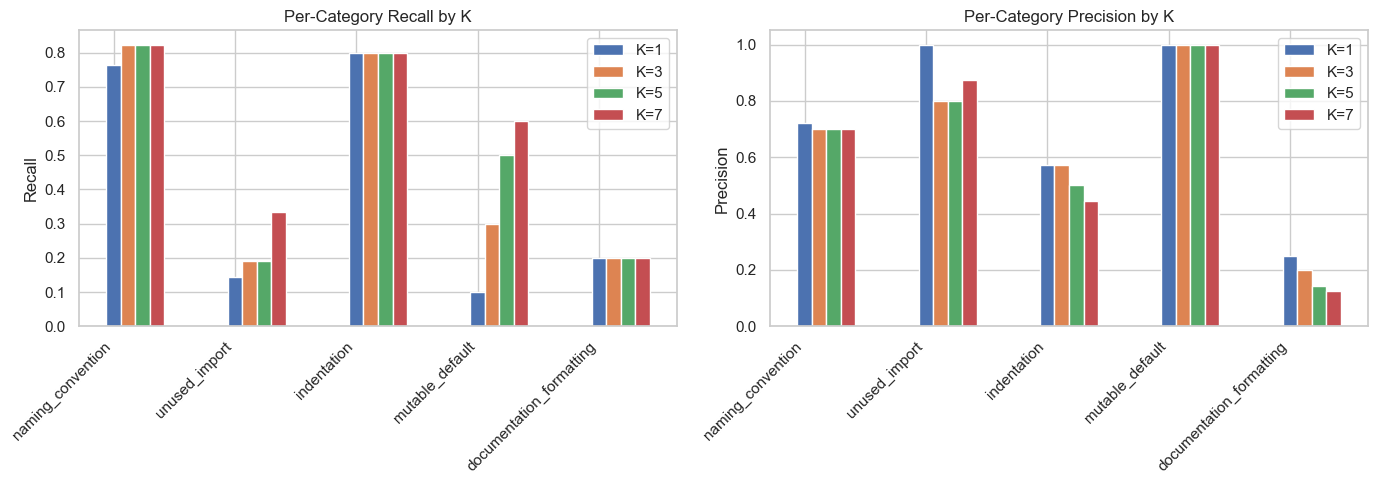

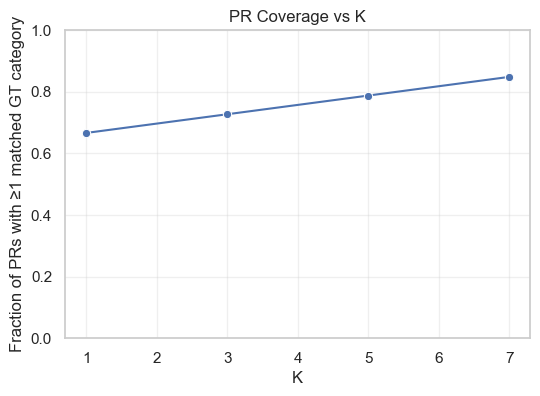

In [15]:
# Statistical overview: per-category TP/FP/recall/precision and simple plots
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Guards: require pr_units computed by the PR-aggregation cell
if 'pr_units' not in globals():
    raise ValueError("Please run the PR-aggregation cell (the one that builds `pr_units`) first.")

# Defaults (use existing notebook values if present)
categories = globals().get('GROUPED_VIOLATION_CATEGORIES', [
    'naming_convention', 'unused_import', 'indentation', 'mutable_default', 'documentation_formatting'
])
k_values = globals().get('k_values', [1, 3, 5, 7])

# Build stats
rows = []
N_prs = len(pr_units)
for k in sorted(k_values):
    for cat in categories:
        gt_count = sum(1 for u in pr_units if cat in (u.get('gt_categories') or []))
        retrieved_count = sum(1 for u in pr_units if cat in (u.get('retrieved_categories') or [])[:k])
        tp = sum(1 for u in pr_units if (cat in (u.get('gt_categories') or [])) and (cat in (u.get('retrieved_categories') or [])[:k]))
        fp = retrieved_count - tp
        rows.append({
            'k': k, 'category': cat,
            'gt_count': gt_count, 'retrieved_count': retrieved_count,
            'tp': tp, 'fp': fp,
            'recall': (tp / gt_count) if gt_count else np.nan,
            'precision': (tp / retrieved_count) if retrieved_count else np.nan
        })

stats_df = pd.DataFrame(rows)

# Coverage: fraction of PRs with at least one matched GT category at K
coverage_rows = []
for k in sorted(k_values):
    matched_prs = 0
    for u in pr_units:
        gt_set = set(u.get('gt_categories') or [])
        topk = [c for c in (u.get('retrieved_categories') or [])[:k] if c]
        if gt_set and any(c in gt_set for c in topk):
            matched_prs += 1
    coverage_rows.append({'k': k, 'pr_coverage': matched_prs / max(1, N_prs)})
coverage_df = pd.DataFrame(coverage_rows)

# Show tables
pd.set_option('display.precision', 3)
print("Per-category stats (rows: k × category)")
display(stats_df)

print("\nCoverage per K (fraction of PRs with ≥1 matched GT category):")
display(coverage_df)

# Top FP examples (sample up to 3 PR ids per category where category was retrieved but not in GT)
fp_examples = {}
for cat in categories:
    examples = []
    for u in pr_units:
        if cat in (u.get('retrieved_categories') or [])[:max(k_values)] and cat not in (u.get('gt_categories') or []):
            examples.append({'id': u['id'], 'repo': u.get('repo'), 'retrieved': u.get('retrieved_categories')})
        if len(examples) >= 3:
            break
    fp_examples[cat] = examples

print("\nSample false-positive PRs (category retrieved but not in GT):")
for cat, ex in fp_examples.items():
    print(f"- {cat}: {len(ex)} sample(s)")
    for e in ex:
        print(f"    id={e['id']}, repo={e['repo']}, retrieved={e['retrieved'][:3]}")

# Simple plots: recall and precision per category for each K, and coverage vs K
sns.set_theme(style='whitegrid')

# Recall plot (one subplot per K)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for k in sorted(k_values):
    dfk = stats_df[stats_df['k'] == k].set_index('category')
    axes[0].bar(np.arange(len(dfk)) + (k_values.index(k)*0.12), dfk['recall'].fillna(0), width=0.12, label=f'K={k}')
axes[0].set_xticks(np.arange(len(categories)))
axes[0].set_xticklabels(categories, rotation=45, ha='right')
axes[0].set_ylabel('Recall')
axes[0].set_title('Per-Category Recall by K')
axes[0].legend()

# Precision plot (grouped)
for k in sorted(k_values):
    dfk = stats_df[stats_df['k'] == k].set_index('category')
    axes[1].bar(np.arange(len(dfk)) + (k_values.index(k)*0.12), dfk['precision'].fillna(0), width=0.12, label=f'K={k}')
axes[1].set_xticks(np.arange(len(categories)))
axes[1].set_xticklabels(categories, rotation=45, ha='right')
axes[1].set_ylabel('Precision')
axes[1].set_title('Per-Category Precision by K')
axes[1].legend()

plt.tight_layout()
plt.show()

# Coverage plot
plt.figure(figsize=(6,4))
sns.lineplot(data=coverage_df, x='k', y='pr_coverage', marker='o')
plt.ylim(0,1)
plt.title('PR Coverage vs K')
plt.xlabel('K')
plt.ylabel('Fraction of PRs with ≥1 matched GT category')
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Save statistical overview outputs to notebooks/v3
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path(PROJECT_ROOT) / "notebooks" if "PROJECT_ROOT" in globals() else Path("notebooks")
out_dir = base_dir / "v2"
out_dir.mkdir(parents=True, exist_ok=True)

saved_files = []

def _save_df(name, obj):
    if obj is None or not hasattr(obj, "to_csv"):
        return
    csv_path = out_dir / f"{name}.csv"
    html_path = out_dir / f"{name}.html"
    obj.to_csv(csv_path, index=False)
    obj.to_html(html_path, index=False)
    saved_files.extend([str(csv_path), str(html_path)])

# Save tables produced by the stats cell (if present)
_save_df("stats_df", globals().get("stats_df"))
_save_df("coverage_df", globals().get("coverage_df"))

# Save all currently open matplotlib figures
for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig_path = out_dir / f"figure_{fig_num}.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    saved_files.append(str(fig_path))

if saved_files:
    print(f"Saved {len(saved_files)} artifacts to: {out_dir}")
    for p in saved_files:
        print(f" - {p}")
else:
    print("No tables/figures found in memory. Run the statistical overview cell first, then re-run this cell.")

Saved 4 artifacts to: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\v2
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\v2\stats_df.csv
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\v2\stats_df.html
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\v2\coverage_df.csv
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\v2\coverage_df.html


,k,cumulative_recall_at_k,cumulative_precision_at_k,cumulative_mrr_at_k
0,1,0.431818,0.666667,0.431818
1,3,0.494949,0.646465,0.456650
2,5,0.540404,0.636364,0.468013
3,7,0.631313,0.658009,0.483165


,k,category,category_recall_contribution
0,1,documentation_formatting,0.200000
1,1,indentation,0.800000
2,1,mutable_default,0.100000
3,1,naming_convention,0.764706
4,1,unused_import,0.142857
5,3,documentation_formatting,0.200000
6,3,indentation,0.800000
7,3,mutable_default,0.300000
8,3,naming_convention,0.823529
9,3,unused_import,0.190476


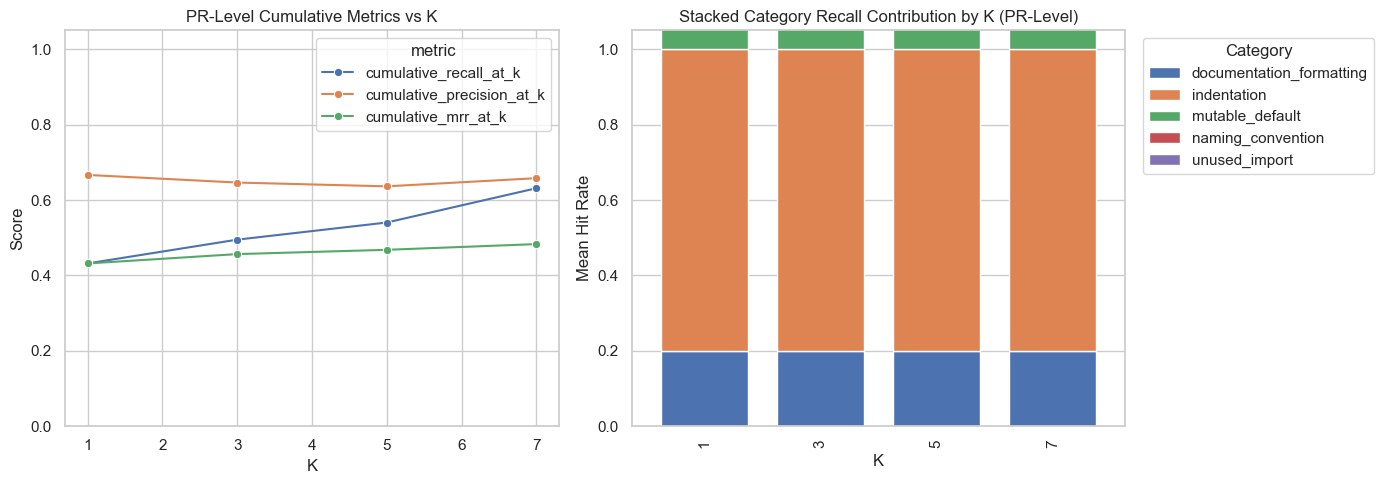

Evaluated 33 PRs for K values: [1, 3, 5, 7]
Metric definitions are PR-level and category-coverage based (as requested).


In [13]:
# PR-level retrieval metrics across multiple K values (custom formulas)
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Edit this list to test any K values you want
k_values = [1, 3, 5, 7]

# Fixed category universe used in this project
GROUPED_VIOLATION_CATEGORIES = [
    'naming_convention',
    'unused_import',
    'indentation',
    'mutable_default',
    'documentation_formatting',
]


def load_ground_truth_map(eval_path, fallback_entries):
    try:
        with open(eval_path, 'r', encoding='utf-8') as f:
            full_eval = json.load(f)
        return {e.get('id'): e.get('ground_truth_reviews') for e in full_eval}
    except Exception:
        return {e.get('id'): e.get('ground_truth_reviews') for e in fallback_entries}


def normalize_gt_categories(gt_list):
    categories = []
    for gt in gt_list or []:
        if isinstance(gt, dict):
            cat = (gt.get('violation_category') or 'unknown').strip()
        else:
            cat = str(gt).strip()
        if cat in GROUPED_VIOLATION_CATEGORIES:
            categories.append(cat)
    return sorted(set(categories))


def extract_payload_category(payload):
    if payload is None:
        return None

    if isinstance(payload, dict):
        obj = payload
    else:
        obj = getattr(payload, 'payload', None)
        if obj is None and isinstance(payload, str):
            try:
                maybe = ast.literal_eval(payload)
                if isinstance(maybe, dict):
                    obj = maybe
            except Exception:
                obj = None

    if isinstance(obj, dict):
        for key in ['violation_category', 'category', 'label', 'violation']:
            val = obj.get(key)
            if isinstance(val, str) and val.strip():
                return val.strip().lower().replace('-', '_').replace(' ', '_')
    return None


def ranked_chunk_categories_for_pr(results, pr_id, max_k):
    rows = results[results['id'] == pr_id]
    rows = rows[rows['query'].notnull()].copy()
    if rows.empty:
        return []

    row = rows.sort_values(by='chunk_index', na_position='last').iloc[0]
    query_text = row['query']
    repo_name = row['repo']

    points = retrieve_guidelines(
        query_text=query_text,
        repo_name=repo_name,
        top_k=max_k,
        client=client,
        embed_model=model,
        collection_name=COLLECTION_NAME,
    )
    return [extract_payload_category(getattr(point, 'payload', None)) for point in points]


def pr_level_metrics(gt_categories, retrieved_categories, k):
    """
    Custom PR-level metrics requested by user.

    Recall@K = matched GT categories / unique GT categories (max 5)
      where a GT category is matched if it appears at least once in Top-K retrieved chunk categories.

    Precision@K = (# retrieved chunks in Top-K whose category is in GT categories) / (# chunks in Top-K)

    MRR@K (modified) = mean over GT categories of reciprocal rank of first match in Top-K.
      For each GT category c: RR_c = 1/rank(first c in Top-K), else 0.
    """
    gt_set = set(gt_categories)
    topk = retrieved_categories[:k]
    topk_non_null = [c for c in topk if c]

    gt_den = min(5, len(gt_set))
    if gt_den == 0:
        return 0.0, 0.0, 0.0

    matched_gt = {c for c in gt_set if c in topk_non_null}
    recall_at_k = len(matched_gt) / gt_den

    if len(topk_non_null) == 0:
        precision_at_k = 0.0
    else:
        precision_at_k = sum(1 for c in topk_non_null if c in gt_set) / len(topk_non_null)

    rr_values = []
    for gt_c in gt_set:
        rr = 0.0
        for rank, c in enumerate(topk_non_null, start=1):
            if c == gt_c:
                rr = 1.0 / rank
                break
        rr_values.append(rr)
    mrr_at_k = sum(rr_values) / len(rr_values) if rr_values else 0.0

    return recall_at_k, precision_at_k, mrr_at_k


gt_map_list = load_ground_truth_map(EVAL_PATH, sampled_entries)

grouped = (
    results_df.groupby('id')
    .agg(
        repo=('repo', 'first'),
        resolved_source_file=('resolved_source_file', 'first')
    )
    .reset_index()
)

k_values = sorted(set(k_values))
max_k = max(k_values)

pr_units = []
for _, row in grouped.iterrows():
    pid = row['id']
    gt_categories = normalize_gt_categories(gt_map_list.get(pid) or [])
    retrieved_categories = ranked_chunk_categories_for_pr(results_df, pid, max_k)
    if gt_categories:
        pr_units.append({
            'id': pid,
            'repo': row['repo'],
            'gt_categories': gt_categories,
            'retrieved_categories': retrieved_categories,
        })

if not pr_units:
    raise ValueError('No PR units with valid ground-truth categories were found.')

records = []
for k in k_values:
    for u in pr_units:
        r_k, p_k, mrr_k = pr_level_metrics(u['gt_categories'], u['retrieved_categories'], k)
        records.append({
            'k': k,
            'id': u['id'],
            'repo': u['repo'],
            'recall_at_k': r_k,
            'precision_at_k': p_k,
            'mrr_at_k': mrr_k,
            'gt_category_count': len(u['gt_categories']),
        })

metrics_long_df = pd.DataFrame(records)
overall_metrics_df = (
    metrics_long_df.groupby('k', as_index=False)[['recall_at_k', 'precision_at_k', 'mrr_at_k']].mean()
    .rename(columns={
        'recall_at_k': 'cumulative_recall_at_k',
        'precision_at_k': 'cumulative_precision_at_k',
        'mrr_at_k': 'cumulative_mrr_at_k',
    })
)

# Category-level recall contribution for stacked bar
category_records = []
for k in k_values:
    for u in pr_units:
        topk = [c for c in u['retrieved_categories'][:k] if c]
        topk_set = set(topk)
        for cat in GROUPED_VIOLATION_CATEGORIES:
            if cat in u['gt_categories']:
                category_records.append({
                    'k': k,
                    'id': u['id'],
                    'category': cat,
                    'hit': 1 if cat in topk_set else 0,
                })

category_metrics_df = pd.DataFrame(category_records)
if not category_metrics_df.empty:
    category_metrics_df = (
        category_metrics_df.groupby(['k', 'category'], as_index=False)['hit'].mean()
        .rename(columns={'hit': 'category_recall_contribution'})
    )

display(overall_metrics_df)
if not category_metrics_df.empty:
    display(category_metrics_df.head(30))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overall_plot_df = overall_metrics_df.melt(
    id_vars='k',
    value_vars=['cumulative_recall_at_k', 'cumulative_precision_at_k', 'cumulative_mrr_at_k'],
    var_name='metric',
    value_name='value',
)
sns.lineplot(data=overall_plot_df, x='k', y='value', hue='metric', marker='o', ax=axes[0])
axes[0].set_title('PR-Level Cumulative Metrics vs K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)

if not category_metrics_df.empty:
    pivot_contrib = (
        category_metrics_df.pivot(index='k', columns='category', values='category_recall_contribution')
        .fillna(0)
        .sort_index()
    )
    pivot_contrib.plot(kind='bar', stacked=True, ax=axes[1], width=0.75)
    axes[1].set_title('Stacked Category Recall Contribution by K (PR-Level)')
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Mean Hit Rate')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
else:
    axes[1].axis('off')
    axes[1].text(0.05, 0.5, 'No category contribution data available', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Evaluated {len(pr_units)} PRs for K values: {k_values}")
print('Metric definitions are PR-level and category-coverage based (as requested).')

In [ ]:
# temp save for results_df.to_csv("retrieval_strategy_2_results.csv", index=False)
# results_df.to_csv("retrieval_strategy_2_results_v2.csv", index=False)

In [14]:
# Save current notebook outputs (tables/DFs + plots) into local notebooks folder
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

base_dir = Path(PROJECT_ROOT) / "notebooks" if "PROJECT_ROOT" in globals() else Path("notebooks")
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = base_dir / f"retrieval_query_strategy_2_exports_{run_tag}"
out_dir.mkdir(parents=True, exist_ok=True)

saved_files = []

def _save_df(name, obj):
    if obj is None or not hasattr(obj, "to_csv"):
        return
    csv_path = out_dir / f"{name}.csv"
    html_path = out_dir / f"{name}.html"
    obj.to_csv(csv_path, index=False)
    obj.to_html(html_path, index=False)
    saved_files.extend([str(csv_path), str(html_path)])

# Save common DataFrames if they exist
_save_df("results_df", globals().get("results_df"))
_save_df("overall_metrics_df", globals().get("overall_metrics_df"))
_save_df("category_metrics_df", globals().get("category_metrics_df"))
_save_df("metrics_long_df", globals().get("metrics_long_df"))

# Save all currently open matplotlib figures (including the plotted diagrams)
fig_nums = plt.get_fignums()
for fig_num in fig_nums:
    fig = plt.figure(fig_num)
    fig_path = out_dir / f"figure_{fig_num}.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    saved_files.append(str(fig_path))

if saved_files:
    print(f"Saved {len(saved_files)} artifacts to: {out_dir}")
    for p in saved_files:
        print(f" - {p}")
else:
    print("No DataFrame/plot artifacts found in memory to save. Run the analysis cells first, then re-run this cell.")

Saved 8 artifacts to: C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\retrieval_query_strategy_2_exports_20260404_113130
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\retrieval_query_strategy_2_exports_20260404_113130\results_df.csv
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\retrieval_query_strategy_2_exports_20260404_113130\results_df.html
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\retrieval_query_strategy_2_exports_20260404_113130\overall_metrics_df.csv
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\retrieval_query_strategy_2_exports_20260404_113130\overall_metrics_df.html
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks\retrieval_query_strategy_2_exports_20260404_113130\category_metrics_df.csv
 - C:\Users\budhi\Documents\IITM\DSAI Lab\Group-1-DS-and-AI-Lab-Project\notebooks